In [ ]:
# Commented out IPython magic to ensure Python compatibility.
# @title Prepare Environment
!pip install torch==2.6
!pip install torchvision==0.21
# %cd /content

!pip install torchsde einops diffusers accelerate
!pip install -q av gguf triton sageattention
!pip install gguf


!pip install av
!git clone https://github.com/Isi-dev/ComfyUI
!cd /content/ComfyUI/custom_nodes
!git clone https://github.com/Isi-dev/ComfyUI_GGUF.git
!cp -pr ComfyUI_GGUF /content/ComfyUI/custom_nodes/
!cd /content/ComfyUI/custom_nodes/ComfyUI_GGUF
!pip install -r requirements.txt
!cd /content/ComfyUI
!apt -y install -qq aria2 ffmpeg

useQ6 = False # @param {"type":"boolean"}

if useQ6:
    !aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/befox/WAN2.2-14B-Rapid-AllInOne-GGUF/resolve/main/v10/wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf?download=true -d /content/ComfyUI/models/unet -o wan2.2-i2v-rapid-aio-v10-nsfw-Q8_K.gguf
else:
    !aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/befox/WAN2.2-14B-Rapid-AllInOne-GGUF/resolve/main/v10/wan2.2-i2v-rapid-aio-v10-nsfw-Q6_K.gguf?download=true -d /content/ComfyUI/models/unet -o wan2.2-i2v-rapid-aio-v10-nsfw-Q8_K.gguf

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/NSFW-API/NSFW-Wan-UMT5-XXL/resolve/main/nsfw_wan_umt5-xxl_fp8_scaled.safetensors?download=true -d /content/ComfyUI/models/text_encoders -o umt5_xxl_fp8_e4m3fn_scaled.safetensors


!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/vae/wan_2.1_vae.safetensors -d /content/ComfyUI/models/vae -o wan_2.1_vae.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/clip_vision/clip_vision_h.safetensors -d /content/ComfyUI/models/clip_vision -o clip_vision_h.safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 11.3 MB/s eta 0:00:00
Cloning into 'ComfyUI'...
remote: Enumerating objects: 25050, done.
remote: Total 25050 (delta 0), reused 0 (delta 0), pack-reused 25050 (from 1)
Receiving objects: 100% (25050/25050), 68.38 MiB | 22.24 MiB/s, done.
Resolving deltas: 100% (16786/16786), done.
Cloning into 'ComfyUI_GGUF'...
remote: Enumerating objects: 677, done.
remote: Counting objects: 100% (438/438), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 677 (delta 390), reused 265 (delta 265), pack-reused 239 (from 2)
Receiving objects: 100% (677/677), 166.43 KiB | 1.36 MiB/s, done.
Resolving deltas: 100% (443/443), done.
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
ffmpeg is already the newest version (7:4.4.2-0ubun

In [ ]:
import torch
import numpy as np
from PIL import Image
import gc
import sys
import random
import os
import imageio
import subprocess
from google.colab import files
from IPython.display import display, HTML, Image as IPImage


os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("PYTORCH_CUDA_ALLOC_CONF set to expandable_segments:True")

sys.path.insert(0, '/content/ComfyUI')

from comfy import model_management

from nodes import (
    CheckpointLoaderSimple,
    CLIPLoader,
    CLIPTextEncode,
    VAEDecode,
    VAELoader,
    KSampler,
    UNETLoader,
    LoadImage,
    CLIPVisionLoader,
    CLIPVisionEncode
)

from custom_nodes.ComfyUI_GGUF.nodes import UnetLoaderGGUF
from comfy_extras.nodes_model_advanced import ModelSamplingSD3
from comfy_extras.nodes_images import SaveAnimatedWEBP
from comfy_extras.nodes_video import SaveWEBM
from comfy_extras.nodes_wan import WanImageToVideo
from comfy import model_management


# Initialize nodes
unet_loader = UnetLoaderGGUF()
model_sampling = ModelSamplingSD3()
clip_loader = CLIPLoader()
clip_encode_positive = CLIPTextEncode()
clip_encode_negative = CLIPTextEncode()
vae_loader = VAELoader()
clip_vision_loader = CLIPVisionLoader()
clip_vision_encode = CLIPVisionEncode()
load_image = LoadImage()
wan_image_to_video = WanImageToVideo()
ksampler = KSampler()
vae_decode = VAEDecode()
save_webp = SaveAnimatedWEBP()
save_webm = SaveWEBM()

def clear_memory(aggressive: bool = True):
    import gc, torch
    # 1) обычный GC
    gc.collect()

    # 2) попросить ComfyUI вычистить/выгрузить модели
    try:
        if aggressive:
            # максимально жёстко (медленнее, но лучше освобождает VRAM)
            model_management.unload_all_models()
        # чистка моделей + gc внутри comfy
        if hasattr(model_management, "cleanup_models_gc"):
            model_management.cleanup_models_gc()
        else:
            model_management.cleanup_models()
    except Exception:
        pass

    # 3) “правильная” очистка кэша по comfy
    try:
        model_management.soft_empty_cache()
    except Exception:
        pass

    # 4) на всякий — torch cache (обычно уже достаточно soft_empty_cache)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

    gc.collect()

########## Работа с изображениями ##########

def save_as_mp4(images, filename_prefix, fps, output_dir="/content/ComfyUI/output"):
    os.makedirs(output_dir, exist_ok=True)
    output_path = f"{output_dir}/{filename_prefix}.mp4"

    frames = [(img.cpu().numpy() * 255).astype(np.uint8) for img in images]

    with imageio.get_writer(output_path, fps=fps) as writer:
        for frame in frames:
            writer.append_data(frame)

    return output_path

def save_as_webp(images, filename_prefix, fps, quality=90, lossless=False, method=4, output_dir="/content/ComfyUI/output"):
    """Save images as animated WEBP using imageio."""
    os.makedirs(output_dir, exist_ok=True)
    output_path = f"{output_dir}/{filename_prefix}.webp"


    frames = [(img.cpu().numpy() * 255).astype(np.uint8) for img in images]


    kwargs = {
        'fps': int(fps),
        'quality': int(quality),
        'lossless': bool(lossless),
        'method': int(method)
    }

    with imageio.get_writer(
        output_path,
        format='WEBP',
        mode='I',
        **kwargs
    ) as writer:
        for frame in frames:
            writer.append_data(frame)

    return output_path

def save_as_webm(images, filename_prefix, fps, codec="vp9", quality=32, output_dir="/content/ComfyUI/output"):
    """Save images as WEBM using imageio."""
    os.makedirs(output_dir, exist_ok=True)
    output_path = f"{output_dir}/{filename_prefix}.webm"


    frames = [(img.cpu().numpy() * 255).astype(np.uint8) for img in images]


    kwargs = {
        'fps': int(fps),
        'quality': int(quality),
        'codec': str(codec),
        'output_params': ['-crf', str(int(quality))]
    }

    with imageio.get_writer(
        output_path,
        format='FFMPEG',
        mode='I',
        **kwargs
    ) as writer:
        for frame in frames:
            writer.append_data(frame)

    return output_path

def save_as_image(image, filename_prefix, output_dir="/content/ComfyUI/output"):
    os.makedirs(output_dir, exist_ok=True)
    output_path = f"{output_dir}/{filename_prefix}.png"

    frame = (image.cpu().numpy() * 255).astype(np.uint8)
    Image.fromarray(frame).save(output_path)

    return output_path



def upload_image():
    """Handle image upload in Colab and store in /content/ComfyUI/input/"""
    from google.colab import files
    import os
    import shutil

    os.makedirs('/content/ComfyUI/input', exist_ok=True)

    uploaded = files.upload()

    # Move each uploaded file to ComfyUI input directory
    for filename in uploaded.keys():
        src_path = f'/content/{filename}'
        dest_path = f'/content/ComfyUI/input/{filename}'

        shutil.move(src_path, dest_path)
        print(f"Image saved to: {dest_path}")
        return dest_path

    return None

########## CLIP similarity ##########

import numpy as np
import torch
import matplotlib.pyplot as plt

def _ensure_bhwc(img: torch.Tensor) -> torch.Tensor:
    # ожидаем [H,W,C] -> делаем [1,H,W,C]
    return img.unsqueeze(0) if img.dim() == 3 else img

def _extract_vec(cv_out):
    """
    Достаём 1 вектор из того, что возвращает CLIPVisionEncode.
    Поддерживаем tensor / dict / object.
    """
    if torch.is_tensor(cv_out):
        v = cv_out
    elif isinstance(cv_out, dict):
        if "image_embeds" in cv_out:
            v = cv_out["image_embeds"]
        elif "pooled_output" in cv_out:
            v = cv_out["pooled_output"]
        elif "last_hidden_state" in cv_out:
            t = cv_out["last_hidden_state"]
            v = t[:, 0] if t.ndim == 3 else t
        else:
            # пробуем первый tensor внутри dict
            v = next((x for x in cv_out.values() if torch.is_tensor(x)), None)
            if v is None:
                raise ValueError(f"Unknown clip vision output dict keys: {list(cv_out.keys())}")
    else:
        # object with attributes
        if hasattr(cv_out, "image_embeds"):
            v = getattr(cv_out, "image_embeds")
        elif hasattr(cv_out, "pooled_output"):
            v = getattr(cv_out, "pooled_output")
        elif hasattr(cv_out, "last_hidden_state"):
            t = getattr(cv_out, "last_hidden_state")
            v = t[:, 0] if t.ndim == 3 else t
        else:
            raise ValueError(f"Unknown clip vision output type: {type(cv_out)}")

    v = v.detach().float()
    if v.ndim > 2:
        v = v.flatten(start_dim=1)
    if v.ndim == 2 and v.shape[0] == 1:
        v = v[0]
    return v

def _cosine(a: torch.Tensor, b: torch.Tensor, eps=1e-8) -> float:
    a = a.flatten()
    b = b.flatten()
    return float((a @ b) / (a.norm() * b.norm() + eps))

@torch.inference_mode()
def clipvision_similarity_curve(decoded_frames, anchor_vec, stride, fps):
    """
    decoded_frames: list/seq of frame tensors [H,W,C] in 0..1
    anchor_vec: 1D tensor on CPU (эмбеддинг якоря)
    """
    clip_vision = clip_vision_loader.load_clip("clip_vision_h.safetensors")[0]

    idxs, sims = [], []
    for i in range(0, len(decoded_frames), stride):
        frame = _ensure_bhwc(decoded_frames[i])
        out = clip_vision_encode.encode(clip_vision, frame, "none")[0]
        vec = _extract_vec(out).cpu()
        sims.append(_cosine(vec, anchor_vec))
        idxs.append(i)

    del clip_vision
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    # в секундах тоже удобно
    times = [i / fps for i in idxs]
    return idxs, times, sims

def plot_similarity(times, sims, title="CLIP-vision similarity over time"):
    plt.figure()
    plt.plot(times, sims)
    plt.ylim(-0.1, 1.0)
    plt.xlabel("time (s)")
    plt.ylabel("cosine similarity")
    plt.title(title)
    plt.show()

import json
import numpy as np
import matplotlib.pyplot as plt

def plot_similarity_combined(clip_log, title="Combined CLIP-vision similarity (all chunks)"):
    """
    clip_log: list of dicts: {prefix, times, sims, stride, fps, frames}
    Рисуем один график, где чанки идут последовательно по оси X,
    а границы чанков отмечаем вертикальными линиями и подписями.
    """
    if not clip_log:
        print("clip_log is empty — nothing to plot.")
        return

    plt.figure(figsize=(14, 5))

    offset = 0.0
    boundaries = []

    for entry in clip_log:
        prefix = entry["prefix"]
        times = np.array(entry["times"], dtype=float)
        sims = np.array(entry["sims"], dtype=float)

        # глобальная шкала времени
        t_global = times + offset
        plt.plot(t_global, sims)

        # граница чанка — в конце его проверки similarity
        end_t = float(t_global[-1]) if len(t_global) else offset
        boundaries.append((end_t, prefix))

        # сдвиг на следующий чанк:
        # берём "реальную" длительность чанка (frames/fps), а не только последнюю точку times
        chunk_seconds = entry.get("frames", 0) / entry.get("fps", 1)
        offset = offset + chunk_seconds

    # вертикальные линии границ + подписи
    for x, prefix in boundaries:
        plt.axvline(x, linestyle="--", linewidth=1, alpha=0.5)
        plt.text(x, 0.02, prefix, rotation=90, va="bottom", ha="right", fontsize=8)

    plt.ylim(-0.1, 1.0)
    plt.xlabel("global time (s)")
    plt.ylabel("cosine similarity")
    plt.title(title)
    plt.show()


def save_clip_log(clip_log, path="/content/ComfyUI/output/clip_similarity_log.json"):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(clip_log, f, ensure_ascii=False, indent=2)
    print(f"✅ Saved clip similarity log: {path}")



########## Генерация ##########
def generate_video(
    image_path: str = None,
    positive_prompt: str = "a cute anime girl...",
    negative_prompt: str = "...",
    width: int = 832,
    height: int = 480,
    seed: int = 82628696717253,
    steps: int = 20,
    cfg_scale: float = 1.0,
    sampler_name: str = "uni_pc",
    scheduler: str = "simple",
    frames: int = 33,
    fps: int = 16,
    output_format: str = "mp4",
    filename_prefix: str = "ComfyUI",
    last_frame_dir: str = "/content/ComfyUI/input",  # <- чтобы сразу было готово как input
    clip_log = None,
    clip_stride=4
):
    output_path = None
    last_frame_path = None

    with torch.inference_mode():
        print("Loading Text_Encoder...")
        clip = clip_loader.load_clip("umt5_xxl_fp8_e4m3fn_scaled.safetensors", "wan", "default")[0]
        positive = clip_encode_positive.encode(clip, positive_prompt)[0]
        negative = clip_encode_negative.encode(clip, negative_prompt)[0]
        del clip
        torch.cuda.empty_cache(); gc.collect()

        if image_path is None:
            print("Please upload an image file:")
            image_path = upload_image()
        if image_path is None:
            print("No image uploaded!")
            return None, None

        loaded_image = load_image.load_image(image_path)[0]
        clip_vision = clip_vision_loader.load_clip("clip_vision_h.safetensors")[0]
        clip_vision_output = clip_vision_encode.encode(clip_vision, loaded_image, "none")[0]

        clip_vision_output = clip_vision_encode.encode(clip_vision, loaded_image, "none")[0]

        # якорь = эмбеддинг входной картинки (дешево и логично для i2v)
        anchor_vec = _extract_vec(clip_vision_output).cpu()

        del clip_vision
        torch.cuda.empty_cache()
        gc.collect()

        print("Loading VAE...")
        vae = vae_loader.load_vae("wan_2.1_vae.safetensors")[0]

        positive_out, negative_out, latent = wan_image_to_video.encode(
            positive, negative, vae, width, height, frames, 1, loaded_image, clip_vision_output
        )

        print("Loading Unet Model...")
        model = unet_loader.load_unet("wan2.2-i2v-rapid-aio-v10-nsfw-Q8_K.gguf")[0]
        model = model_sampling.patch(model, 5)[0]

        print("Generating video...")
        sampled = ksampler.sample(
            model=model,
            seed=seed,
            steps=steps,
            cfg=cfg_scale,
            sampler_name=sampler_name,
            scheduler=scheduler,
            positive=positive_out,
            negative=negative_out,
            latent_image=latent
        )[0]

        del model
        torch.cuda.empty_cache(); gc.collect()

        try:
            print("Decoding latents...")
            decoded = vae_decode.decode(vae, sampled)[0]

            # --- CLIP-Vision similarity (после генерации, когда UNet уже выгружен) ---
            stride = clip_stride  # чем больше, тем дешевле (4 = каждый 4-й кадр)
            idxs, times, sims = clipvision_similarity_curve(decoded, anchor_vec, stride=stride, fps=fps)
            plot_similarity(times, sims, title=f"{filename_prefix}: similarity to input image (stride={stride})")

            if clip_log is not None:
              clip_log.append({
                  "prefix": filename_prefix,
                  "times": times,     # локальные времена внутри чанка
                  "sims": sims,       # значения similarity
                  "stride": stride,
                  "fps": fps,
                  "frames": frames
              })



            # --- ВОТ ТУТ: сохраняем последний кадр ---
            # decoded обычно список кадров; если вдруг тензор [T,H,W,C], decoded[-1] тоже ок
            last_frame = decoded[-1] if frames > 1 else decoded[0]
            last_frame_path = save_as_image(
                last_frame,
                f"{filename_prefix}_lastframe",
                output_dir=last_frame_dir
            )
            print(f"Last frame saved to: {last_frame_path}")

            del vae
            torch.cuda.empty_cache(); gc.collect()

            if frames == 1:
                output_path = save_as_image(decoded[0], filename_prefix, output_dir="/content/ComfyUI/output")
                display(IPImage(filename=output_path))
            else:
                if output_format.lower() == "webm":
                    output_path = save_as_webm(decoded, filename_prefix, fps=fps, codec="vp9", quality=10)
                elif output_format.lower() == "mp4":
                    output_path = save_as_mp4(decoded, filename_prefix, fps)
                else:
                    raise ValueError(f"Unsupported output format: {output_format}")

                display_video(output_path)

        finally:
            clear_memory()

    return output_path, last_frame_path


def display_video(video_path):
    from IPython.display import HTML
    from base64 import b64encode

    video_data = open(video_path,'rb').read()

    # Determine MIME type based on file extension
    if video_path.lower().endswith('.mp4'):
        mime_type = "video/mp4"
    elif video_path.lower().endswith('.webm'):
        mime_type = "video/webm"
    elif video_path.lower().endswith('.webp'):
        mime_type = "image/webp"
    else:
        mime_type = "video/mp4"  # default

    data_url = f"data:{mime_type};base64," + b64encode(video_data).decode()

    display(HTML(f"""
    <video width=512 controls autoplay loop>
        <source src="{data_url}" type="{mime_type}">
    </video>
    """))

print("✅ Environment Setup Complete!")


"""# New Section"""

def run_chunk_loop(
    n_chunks: int = 10,
    start_image_path: str = None,
    same_seed: bool = False,
    **gen_kwargs
):
    clip_log = []
    if start_image_path is None:
        print("Upload start image:")
        start_image_path = upload_image()
        if start_image_path is None:
            print("No image uploaded!")
            return [], None

    current_image = start_image_path
    videos = []

    for i in range(n_chunks):
        print(f"\n====================")
        print(f"CHUNK {i+1}/{n_chunks}")
        print(f"Input image: {current_image}")
        print(f"====================\n")

        if "seed" in gen_kwargs and not same_seed:
            gen_kwargs["seed"] = random.randint(0, 2**32 - 1)
            print(f"Using seed: {gen_kwargs['seed']}")

        prefix = f"video_{i+1:03d}"
        gen_kwargs["filename_prefix"] = prefix
        positive_prompt = "anime girl dancing disco, full body,steady character identity, big red cat dancing next to her, simple clean disco stage, mirror ball, soft neon lighting, gentle camera movement: slow pan left to right, slight zoom in, smooth animation, clear readable motion, consistent outfit, consistent face, no sudden scene changes, no cuts, no flicker, high detail, clean edges, crisp lineart, vibrant but controlled colors" # {"type":"string"}
        negative_prompt = "plastic skin, shinny skin, white skin, unnatural skin, skin smoothness, smooth skinwithout testicles, good skin, unnatural skin, shinny skin, skin pores, skin plastic, smooth skins, bad anatomy, morbid anatomy, worst quality, low quality, normal quality, low res, blurry, grainy, pixelated:1.4) deformed, distorted, disfigured, mutation, mutated, bad anatomy, wrong anatomy, inaccurate anatomy poorly drawn face, poorly drawn hands, missing fingers, extra fingers, fused fingers, extra limbs, missing limbs cartoon, anime, illustration, 3d, cgi, sketch, painting, drawing watermark, text, signature, logo monochrome, b&w " # {"type":"string"}
        width = 384 # {"type":"number"}
        height = 640 # {"type":"number"}
        seed = 0 # {"type":"integer"}
        steps = 4 # {"type":"integer", "min":1, "max":100}
        cfg_scale = 1 # {"type":"number", "min":1, "max":20}
        sampler_name = "euler" # ["uni_pc", "euler", "dpmpp_2m", "ddim", "lms"]
        scheduler = "simple" # ["simple", "normal", "karras", "exponential"]
        frames = 61 # {"type":"integer", "min":1, "max":120}
        fps = 8 # {"type":"integer", "min":1, "max":60}
        output_format = "mp4" # ["mp4", "webm"]

        output_path, last_frame_path = generate_video(
            image_path=current_image,
                positive_prompt=positive_prompt,
                negative_prompt=negative_prompt,
                width=width,
                height=height,
                seed=seed,
                steps=steps,
                cfg_scale=cfg_scale,
                sampler_name=sampler_name,
                scheduler=scheduler,
                frames=frames,
                fps=fps,
                output_format=output_format,
                filename_prefix=prefix,
                clip_log=clip_log,
                clip_stride=4
        )

        if output_path:
            print(f"Saved video: {output_path}")
            videos.append(output_path)

        if last_frame_path is None:
            print("Failed to get last frame. Stopping loop.")
            return videos, None

        current_image = last_frame_path

        clear_memory()
    save_clip_log(clip_log)
    plot_similarity_combined(clip_log, title="All chunks: similarity to input image (with chunk boundaries)")

    print(f"\nLoop finished. Last frame for next run: {current_image}")
    return videos, current_image


PYTORCH_CUDA_ALLOC_CONF set to expandable_segments:True
✅ Environment Setup Complete!


Upload start image:


Saving images-2.jpeg to images-2.jpeg
Image saved to: /content/ComfyUI/input/images-2.jpeg

CHUNK 1/3
Input image: /content/ComfyUI/input/images-2.jpeg

Loading Text_Encoder...


Loading VAE...
Loading Unet Model...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (326)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...


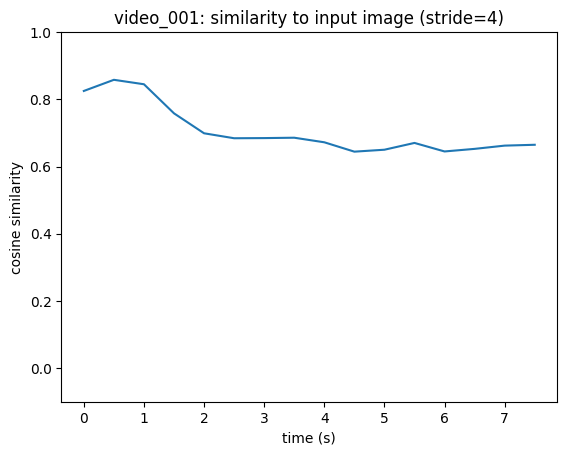

Last frame saved to: /content/ComfyUI/input/video_001_lastframe.png


Saved video: /content/ComfyUI/output/video_001.mp4

CHUNK 2/3
Input image: /content/ComfyUI/input/video_001_lastframe.png

Loading Text_Encoder...


Loading VAE...
Loading Unet Model...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (326)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...


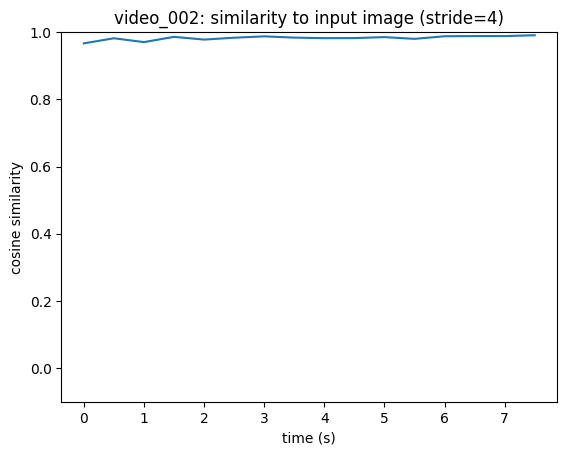

Last frame saved to: /content/ComfyUI/input/video_002_lastframe.png


Saved video: /content/ComfyUI/output/video_002.mp4

CHUNK 3/3
Input image: /content/ComfyUI/input/video_002_lastframe.png

Loading Text_Encoder...


Loading VAE...
Loading Unet Model...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (326)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...


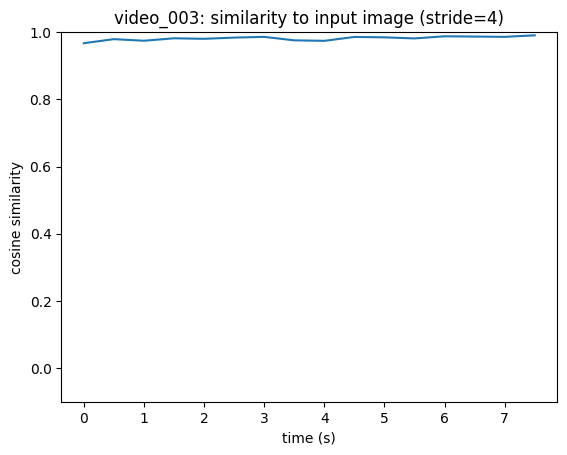

Last frame saved to: /content/ComfyUI/input/video_003_lastframe.png


Saved video: /content/ComfyUI/output/video_003.mp4
✅ Saved clip similarity log: /content/ComfyUI/output/clip_similarity_log.json


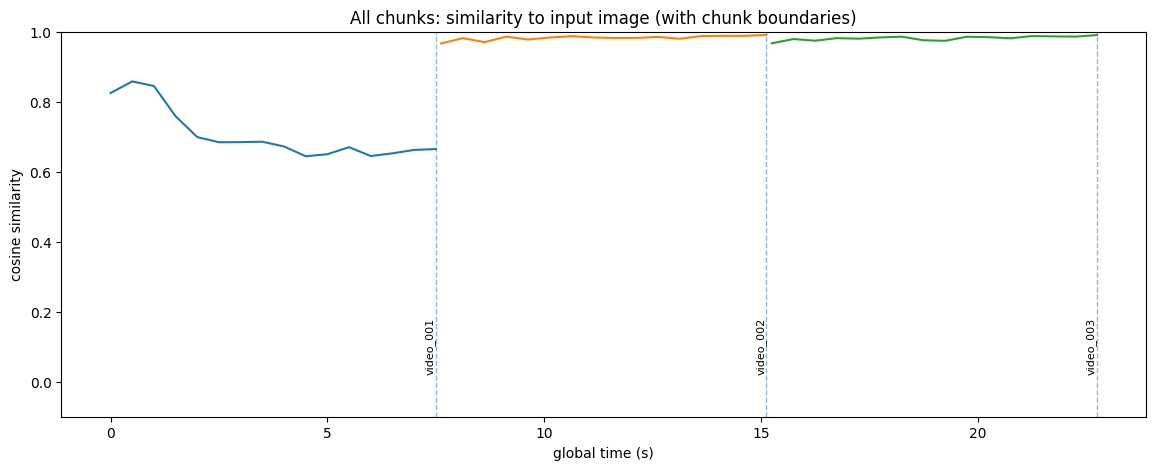


Loop finished. Last frame for next run: /content/ComfyUI/input/video_003_lastframe.png


(['/content/ComfyUI/output/video_001.mp4',
  '/content/ComfyUI/output/video_002.mp4',
  '/content/ComfyUI/output/video_003.mp4'],
 '/content/ComfyUI/input/video_003_lastframe.png')

In [ ]:
run_chunk_loop(n_chunks = 3)

In [ ]:
# @title Generate Video

positive_prompt = "anime girl is dancing disco with big red cat" # @param {"type":"string"}
negative_prompt = "plastic skin, shinny skin, white skin, unnatural skin, skin smoothness, smooth skinwithout testicles, good skin, unnatural skin, shinny skin, skin pores, skin plastic, smooth skins, bad anatomy, morbid anatomy, worst quality, low quality, normal quality, low res, blurry, grainy, pixelated:1.4) deformed, distorted, disfigured, mutation, mutated, bad anatomy, wrong anatomy, inaccurate anatomy poorly drawn face, poorly drawn hands, missing fingers, extra fingers, fused fingers, extra limbs, missing limbs cartoon, anime, illustration, 3d, cgi, sketch, painting, drawing watermark, text, signature, logo monochrome, b&w " # @param {"type":"string"}
width = 480 # @param {"type":"number"}
height = 816 # @param {"type":"number"}
seed = 0 # @param {"type":"integer"}
steps = 4 # @param {"type":"integer", "min":1, "max":100}
cfg_scale = 1 # @param {"type":"number", "min":1, "max":20}
sampler_name = "euler" # @param ["uni_pc", "euler", "dpmpp_2m", "ddim", "lms"]
scheduler = "simple" # @param ["simple", "normal", "karras", "exponential"]
frames = 61 # @param {"type":"integer", "min":1, "max":120}
fps = 8 # @param {"type":"integer", "min":1, "max":60}
output_format = "mp4" # @param ["mp4", "webm"]

import random
seed = seed if seed != 0 else random.randint(0, 2**32 - 1)
print(f"Using seed: {seed}")

# with torch.inference_mode():
generate_video(
    image_path=None,
    positive_prompt=positive_prompt,
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    seed=seed,
    steps=steps,
    cfg_scale=cfg_scale,
    sampler_name=sampler_name,
    scheduler=scheduler,
    frames=frames,
    fps=fps,
    output_format=output_format
)
clear_memory()

Using seed: 233636813
Loading Text_Encoder...


Please upload an image file:


Saving images-2.jpeg to images-2.jpeg
Image saved to: /content/ComfyUI/input/images-2.jpeg
Loading VAE...
Loading Unet Model...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (410)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...
Last frame saved to: /content/ComfyUI/input/ComfyUI_lastframe.png


In [ ]:
dir(model_management)


['CPUState',
 'DISABLE_SMART_MEMORY',
 'ENABLE_PYTORCH_ATTENTION',
 'EXTRA_RESERVED_VRAM',
 'Enum',
 'FLOAT8_TYPES',
 'FORCE_FP32',
 'InterruptProcessingException',
 'LoadedModel',
 'MIN_WEIGHT_MEMORY_RATIO',
 'OOM_EXCEPTION',
 'PRIORITIZE_FP16',
 'PerformanceFeature',
 'VRAMState',
 'WINDOWS',
 'XFORMERS_ENABLED_VAE',
 'XFORMERS_IS_AVAILABLE',
 'XFORMERS_VERSION',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'args',
 'cast_to',
 'cast_to_device',
 'cleanup_models',
 'cleanup_models_gc',
 'cpu_mode',
 'cpu_state',
 'current_loaded_models',
 'device_should_use_non_blocking',
 'device_supports_non_blocking',
 'directml_enabled',
 'dtype_size',
 'extra_reserved_memory',
 'flash_attention_enabled',
 'force_channels_last',
 'force_upcast_attention_dtype',
 'free_memory',
 'gc',
 'get_autocast_device',
 'get_free_memory',
 'get_supported_float8_types',
 'get_torch_device',
 'get_torch_device_name',
 'get_total_memory',
 'i

In [ ]:
generate_video(
    image_path='/content/ComfyUI/input/ComfyUI_lastframe.png',
    positive_prompt=positive_prompt,
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    seed=seed,
    steps=steps,
    cfg_scale=cfg_scale,
    sampler_name=sampler_name,
    scheduler=scheduler,
    frames=frames,
    fps=fps,
    output_format=output_format
)

Loading Text_Encoder...


Loading VAE...
Loading Unet Model...
gguf qtypes: F16 (821), Q6_K (480), F32 (2)
Generating video...
Attempting to release mmap (410)


  0%|          | 0/4 [00:00<?, ?it/s]

Decoding latents...
Last frame saved to: /content/ComfyUI/input/ComfyUI_lastframe.png


('/content/ComfyUI/output/ComfyUI.mp4',
 '/content/ComfyUI/input/ComfyUI_lastframe.png')

In [ ]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import torch
import gc
from IPython.display import Image as IPImage

# Adapted from Omni-WorldBench (arXiv:2603.22212v1):
# - generated video quality proxies from Sec. 4.2
# - InterStab-L-style long-horizon consistency from Sec. 4.4
# - AgenticScore-like weighted aggregation from Sec. 4.5


DEFAULT_CHUNK_QUALITY_CFG = {
    "chunk_threshold": 0.72,
    "content_alignment_min": 0.72,
    "interstab_l_min": 0.58,
    "temporal_flickering_min": 0.50,
    "motion_smoothness_min": 0.52,
    "dynamic_degree_min": 0.40,
    "transitions_detect_min": 0.75,
    "dynamic_band_low": 0.02,
    "dynamic_band_high": 0.18,
    "dynamic_band_cap": 0.30,
    "static_guard": 0.985,
    "hard_cut_threshold": 0.32,
    "max_metric_samples": 7,
    "weights": {
        "interaction_effect_fidelity": 0.55,
        "generated_video_quality": 0.45,
    },
}


def _merge_quality_cfg(quality_cfg=None):
    cfg = deepcopy(DEFAULT_CHUNK_QUALITY_CFG)
    if not quality_cfg:
        return cfg
    for key, value in quality_cfg.items():
        if key == "weights" and isinstance(value, dict):
            cfg["weights"].update(value)
        else:
            cfg[key] = value
    return cfg


def _ensure_bhwc_local(img: torch.Tensor) -> torch.Tensor:
    return img.unsqueeze(0) if img.dim() == 3 else img


def _frame_to_numpy(frame) -> np.ndarray:
    if torch.is_tensor(frame):
        arr = frame.detach().float().cpu().numpy()
    else:
        arr = np.asarray(frame, dtype=np.float32)
    if arr.ndim == 4:
        arr = arr[0]
    arr = np.clip(arr, 0.0, 1.0)
    return arr.astype(np.float32, copy=False)


def _gray(frame: np.ndarray) -> np.ndarray:
    if frame.ndim == 2:
        return frame
    return (
        0.2989 * frame[..., 0]
        + 0.5870 * frame[..., 1]
        + 0.1140 * frame[..., 2]
    ).astype(np.float32, copy=False)


def _simple_ssim(a: np.ndarray, b: np.ndarray) -> float:
    x = _gray(_frame_to_numpy(a))
    y = _gray(_frame_to_numpy(b))
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    mu_x = float(x.mean())
    mu_y = float(y.mean())
    sigma_x = float(x.var())
    sigma_y = float(y.var())
    sigma_xy = float(((x - mu_x) * (y - mu_y)).mean())

    num = (2.0 * mu_x * mu_y + c1) * (2.0 * sigma_xy + c2)
    den = (mu_x ** 2 + mu_y ** 2 + c1) * (sigma_x + sigma_y + c2)
    if den <= 1e-8:
        return 0.0
    return float(np.clip(num / den, 0.0, 1.0))


def _cosine_safe(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> float:
    a = a.detach().float().flatten().cpu()
    b = b.detach().float().flatten().cpu()
    denom = float(a.norm() * b.norm()) + eps
    if denom <= eps:
        return 0.0
    return float(torch.dot(a, b) / denom)


def _mean_or_default(values, default=0.0) -> float:
    return float(np.mean(values)) if values else float(default)


def _normalize(value: float, lo: float, hi: float, invert: bool = False) -> float:
    if hi <= lo:
        score = 1.0
    else:
        score = (value - lo) / (hi - lo)
    score = float(np.clip(score, 0.0, 1.0))
    return float(1.0 - score) if invert else score


def _band_score(value: float, lo: float, hi: float, cap: float) -> float:
    if value < 0.0:
        return 0.0
    if lo <= value <= hi:
        return 1.0
    if value < lo:
        if lo <= 1e-8:
            return 0.0
        return float(np.clip(value / lo, 0.0, 1.0))
    if cap <= hi:
        return 0.0
    return float(np.clip(1.0 - ((value - hi) / (cap - hi)), 0.0, 1.0))


def _sample_indices(num_frames: int, max_samples: int) -> list[int]:
    if num_frames <= 0:
        return []
    sample_count = max(2, min(int(max_samples), int(num_frames)))
    if sample_count >= num_frames:
        return list(range(num_frames))
    idxs = np.linspace(0, num_frames - 1, num=sample_count)
    return sorted({int(round(x)) for x in idxs})


def _spatial_detail(frame: np.ndarray) -> float:
    gray = _gray(frame)
    if gray.shape[0] < 2 or gray.shape[1] < 2:
        return 0.0
    gx = np.diff(gray, axis=1)
    gy = np.diff(gray, axis=0)
    gx = gx[: gy.shape[0], :]
    gy = gy[:, : gx.shape[1]]
    grad_mag = np.sqrt(gx * gx + gy * gy)
    return float(grad_mag.mean())


@torch.inference_mode()
def evaluate_chunk_metrics(
    decoded_frames,
    anchor_vec,
    *,
    fps: int,
    clip_stride: int = 4,
    quality_cfg=None,
):
    cfg = _merge_quality_cfg(quality_cfg)
    num_frames = len(decoded_frames)
    if num_frames == 0:
        raise ValueError("decoded_frames is empty")

    clip_vision = clip_vision_loader.load_clip("clip_vision_h.safetensors")[0]

    curve_idxs = list(range(0, num_frames, max(1, int(clip_stride))))
    if curve_idxs[-1] != num_frames - 1:
        curve_idxs.append(num_frames - 1)

    sample_idxs = _sample_indices(num_frames, cfg["max_metric_samples"])
    idx_union = sorted(set(curve_idxs + sample_idxs))

    embeds = {}
    anchor_sims = {}
    frames_np = {}

    for idx in idx_union:
        frame = decoded_frames[idx]
        frame_bhwc = _ensure_bhwc_local(frame)
        clip_out = clip_vision_encode.encode(clip_vision, frame_bhwc, "none")[0]
        vec = _extract_vec(clip_out).cpu()
        embeds[idx] = vec
        anchor_sims[idx] = _cosine_safe(vec, anchor_vec)
        frames_np[idx] = _frame_to_numpy(frame)

    del clip_vision
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    times = [idx / fps for idx in curve_idxs]
    sims = [anchor_sims[idx] for idx in curve_idxs]

    sampled_frames = [frames_np[idx] for idx in sample_idxs]
    sampled_embeds = [embeds[idx] for idx in sample_idxs]
    sampled_anchor_sims = [anchor_sims[idx] for idx in sample_idxs]

    pair_diffs = []
    pair_semantic = []
    for prev_frame, next_frame, prev_vec, next_vec in zip(
        sampled_frames[:-1],
        sampled_frames[1:],
        sampled_embeds[:-1],
        sampled_embeds[1:],
    ):
        pair_diffs.append(float(np.mean(np.abs(next_frame - prev_frame))))
        pair_semantic.append(_cosine_safe(prev_vec, next_vec))

    diff_jitter = [abs(b - a) for a, b in zip(pair_diffs[:-1], pair_diffs[1:])]

    detail_vals = [_spatial_detail(frame) for frame in sampled_frames]
    imaging_quality = _normalize(_mean_or_default(detail_vals), 0.015, 0.08)
    content_alignment = float(np.clip(_mean_or_default(sampled_anchor_sims), 0.0, 1.0))

    dynamic_raw = _mean_or_default(pair_diffs)
    dynamic_degree = _band_score(
        dynamic_raw,
        cfg["dynamic_band_low"],
        cfg["dynamic_band_high"],
        cfg["dynamic_band_cap"],
    )

    temporal_flickering = _normalize(_mean_or_default(diff_jitter), 0.0, 0.06, invert=True)
    motion_smoothness = _normalize(np.std(pair_diffs) if pair_diffs else 0.0, 0.0, 0.08, invert=True)

    hard_cut_ratio = _mean_or_default(
        [1.0 if diff > cfg["hard_cut_threshold"] else 0.0 for diff in pair_diffs],
        default=0.0,
    )
    transitions_detect = float(np.clip(1.0 - hard_cut_ratio, 0.0, 1.0))

    revisit_pairs = []
    if len(sample_idxs) >= 2:
        mid = len(sample_idxs) // 2
        revisit_pairs.append((0, len(sample_idxs) - 1))
        revisit_pairs.append((0, mid))
        revisit_pairs.append((max(0, mid - 1), min(len(sample_idxs) - 1, mid + 1)))

    revisit_scores = []
    for left, right in revisit_pairs:
        if left == right:
            continue
        ssim_score = _simple_ssim(sampled_frames[left], sampled_frames[right])
        semantic_score = _cosine_safe(sampled_embeds[left], sampled_embeds[right])
        revisit_scores.append(0.4 * ssim_score + 0.6 * semantic_score)

    static_anchor = _mean_or_default(pair_semantic, default=1.0)
    if static_anchor >= cfg["static_guard"] and dynamic_raw < cfg["dynamic_band_low"]:
        interstab_l = 0.0
    else:
        interstab_l = float(np.clip(_mean_or_default(revisit_scores, default=content_alignment), 0.0, 1.0))

    generated_video_quality = float(
        np.mean(
            [
                imaging_quality,
                temporal_flickering,
                content_alignment,
                motion_smoothness,
                dynamic_degree,
            ]
        )
    )
    interaction_effect_fidelity = float(
        np.mean(
            [
                interstab_l,
                transitions_detect,
                content_alignment,
            ]
        )
    )

    weights = cfg["weights"]
    chunk_score = float(
        weights["interaction_effect_fidelity"] * interaction_effect_fidelity
        + weights["generated_video_quality"] * generated_video_quality
    )

    metrics = {
        "imaging_quality": imaging_quality,
        "temporal_flickering": temporal_flickering,
        "content_alignment": content_alignment,
        "motion_smoothness": motion_smoothness,
        "dynamic_degree": dynamic_degree,
        "dynamic_degree_raw": dynamic_raw,
        "transitions_detect": transitions_detect,
        "interstab_l": interstab_l,
        "generated_video_quality": generated_video_quality,
        "interaction_effect_fidelity": interaction_effect_fidelity,
        "chunk_score": chunk_score,
        "static_anchor_similarity": static_anchor,
        "sample_indices": sample_idxs,
        "curve_indices": curve_idxs,
        "curve_times": times,
        "curve_sims": sims,
    }
    return metrics


def accept_chunk(metrics, quality_cfg=None):
    cfg = _merge_quality_cfg(quality_cfg)
    fail_reasons = []

    checks = [
        ("content_alignment", cfg["content_alignment_min"]),
        ("interstab_l", cfg["interstab_l_min"]),
        ("temporal_flickering", cfg["temporal_flickering_min"]),
        ("motion_smoothness", cfg["motion_smoothness_min"]),
        ("dynamic_degree", cfg["dynamic_degree_min"]),
        ("transitions_detect", cfg["transitions_detect_min"]),
        ("chunk_score", cfg["chunk_threshold"]),
    ]

    for metric_name, threshold in checks:
        value = float(metrics.get(metric_name, 0.0))
        if value < threshold:
            fail_reasons.append(f"{metric_name}={value:.3f} < {threshold:.3f}")

    accepted = len(fail_reasons) == 0
    return accepted, fail_reasons


def plot_chunk_scores(chunk_history, title="Chunk scores across attempts"):
    if not chunk_history:
        print("chunk_history is empty")
        return

    xs = []
    ys = []
    labels = []
    for item in chunk_history:
        xs.append(len(xs) + 1)
        ys.append(item["metrics"]["chunk_score"])
        labels.append(f"c{item['chunk_idx']+1}-t{item['attempt']}")

    plt.figure(figsize=(14, 4))
    plt.plot(xs, ys, marker="o")
    plt.xticks(xs, labels, rotation=45, ha="right")
    plt.ylim(0.0, 1.0)
    plt.ylabel("chunk_score")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.show()


def generate_video_scored(
    image_path: str = None,
    positive_prompt: str = "a cute anime girl...",
    negative_prompt: str = "...",
    width: int = 832,
    height: int = 480,
    seed: int = 82628696717253,
    steps: int = 20,
    cfg_scale: float = 1.0,
    sampler_name: str = "uni_pc",
    scheduler: str = "simple",
    frames: int = 33,
    fps: int = 16,
    output_format: str = "mp4",
    filename_prefix: str = "ComfyUI",
    last_frame_dir: str = "/content/ComfyUI/input",
    clip_log=None,
    clip_stride: int = 4,
    quality_cfg=None,
):
    quality_cfg = _merge_quality_cfg(quality_cfg)
    output_path = None
    last_frame_path = None

    with torch.inference_mode():
        print("Loading Text_Encoder...")
        clip = clip_loader.load_clip("umt5_xxl_fp8_e4m3fn_scaled.safetensors", "wan", "default")[0]
        positive = clip_encode_positive.encode(clip, positive_prompt)[0]
        negative = clip_encode_negative.encode(clip, negative_prompt)[0]
        del clip
        torch.cuda.empty_cache()
        gc.collect()

        if image_path is None:
            print("Please upload an image file:")
            image_path = upload_image()
        if image_path is None:
            print("No image uploaded!")
            return None

        loaded_image = load_image.load_image(image_path)[0]
        clip_vision = clip_vision_loader.load_clip("clip_vision_h.safetensors")[0]
        clip_vision_output = clip_vision_encode.encode(clip_vision, loaded_image, "none")[0]
        anchor_vec = _extract_vec(clip_vision_output).cpu()
        del clip_vision
        torch.cuda.empty_cache()
        gc.collect()

        print("Loading VAE...")
        vae = vae_loader.load_vae("wan_2.1_vae.safetensors")[0]

        positive_out, negative_out, latent = wan_image_to_video.encode(
            positive,
            negative,
            vae,
            width,
            height,
            frames,
            1,
            loaded_image,
            clip_vision_output,
        )

        print("Loading Unet Model...")
        model = unet_loader.load_unet("wan2.2-i2v-rapid-aio-v10-nsfw-Q8_K.gguf")[0]
        model = model_sampling.patch(model, 5)[0]

        print(f"Generating video with seed={seed} ...")
        sampled = ksampler.sample(
            model=model,
            seed=seed,
            steps=steps,
            cfg=cfg_scale,
            sampler_name=sampler_name,
            scheduler=scheduler,
            positive=positive_out,
            negative=negative_out,
            latent_image=latent,
        )[0]

        del model
        torch.cuda.empty_cache()
        gc.collect()

        try:
            print("Decoding latents...")
            decoded = vae_decode.decode(vae, sampled)[0]
            metrics = evaluate_chunk_metrics(
                decoded,
                anchor_vec,
                fps=fps,
                clip_stride=clip_stride,
                quality_cfg=quality_cfg,
            )
            accepted, fail_reasons = accept_chunk(metrics, quality_cfg=quality_cfg)

            plot_similarity(
                metrics["curve_times"],
                metrics["curve_sims"],
                title=f"{filename_prefix}: similarity to input image",
            )

            print(
                "Chunk metrics:",
                {
                    "chunk_score": round(metrics["chunk_score"], 4),
                    "interstab_l": round(metrics["interstab_l"], 4),
                    "content_alignment": round(metrics["content_alignment"], 4),
                    "temporal_flickering": round(metrics["temporal_flickering"], 4),
                    "motion_smoothness": round(metrics["motion_smoothness"], 4),
                    "dynamic_degree": round(metrics["dynamic_degree"], 4),
                    "transitions_detect": round(metrics["transitions_detect"], 4),
                },
            )
            print("Accepted:", accepted)
            if fail_reasons:
                print("Fail reasons:", fail_reasons)

            if clip_log is not None:
                clip_log.append(
                    {
                        "prefix": filename_prefix,
                        "times": metrics["curve_times"],
                        "sims": metrics["curve_sims"],
                        "stride": clip_stride,
                        "fps": fps,
                        "frames": frames,
                        "metrics": {
                            k: v
                            for k, v in metrics.items()
                            if k not in {"sample_indices", "curve_indices", "curve_times", "curve_sims"}
                        },
                        "accepted": accepted,
                        "fail_reasons": fail_reasons,
                        "seed": seed,
                    }
                )

            last_frame = decoded[-1] if frames > 1 else decoded[0]
            last_frame_path = save_as_image(
                last_frame,
                f"{filename_prefix}_lastframe",
                output_dir=last_frame_dir,
            )
            print(f"Last frame saved to: {last_frame_path}")

            del vae
            torch.cuda.empty_cache()
            gc.collect()

            if frames == 1:
                output_path = save_as_image(decoded[0], filename_prefix, output_dir="/content/ComfyUI/output")
                display(IPImage(filename=output_path))
            else:
                if output_format.lower() == "webm":
                    output_path = save_as_webm(decoded, filename_prefix, fps=fps, codec="vp9", quality=10)
                elif output_format.lower() == "mp4":
                    output_path = save_as_mp4(decoded, filename_prefix, fps)
                else:
                    raise ValueError(f"Unsupported output format: {output_format}")

                display_video(output_path)

        finally:
            clear_memory()

    return {
        "output_path": output_path,
        "last_frame_path": last_frame_path,
        "metrics": metrics,
        "accepted": accepted,
        "fail_reasons": fail_reasons,
        "seed": seed,
        "filename_prefix": filename_prefix,
    }


def run_chunk_loop_with_regeneration(
    n_chunks: int = 10,
    start_image_path: str = None,
    same_seed: bool = False,
    max_retries: int = 2,
    fallback_to_best: bool = True,
    quality_cfg=None,
    **gen_kwargs,
):
    quality_cfg = _merge_quality_cfg(quality_cfg)
    clip_log = []
    chunk_history = []

    if start_image_path is None:
        print("Upload start image:")
        start_image_path = upload_image()
        if start_image_path is None:
            print("No image uploaded!")
            return [], None, []

    current_image = start_image_path
    accepted_videos = []

    for chunk_idx in range(n_chunks):
        print("\n====================")
        print(f"CHUNK {chunk_idx + 1}/{n_chunks}")
        print(f"Input image: {current_image}")
        print("====================\n")

        best_result = None
        accepted_result = None

        for attempt in range(max_retries + 1):
            local_kwargs = dict(gen_kwargs)
            if "seed" in local_kwargs:
                base_seed = int(local_kwargs["seed"])
            else:
                base_seed = random.randint(0, 2**32 - 1)

            if same_seed and attempt == 0:
                seed = base_seed
            else:
                seed = random.randint(0, 2**32 - 1)

            prefix = f"video_{chunk_idx + 1:03d}_try_{attempt + 1:02d}"
            result = generate_video_scored(
                image_path=current_image,
                filename_prefix=prefix,
                clip_log=clip_log,
                clip_stride=local_kwargs.pop("clip_stride", 4),
                quality_cfg=quality_cfg,
                seed=seed,
                **local_kwargs,
            )
            if result is None:
                break

            history_item = {
                "chunk_idx": chunk_idx,
                "attempt": attempt + 1,
                "seed": seed,
                "metrics": result["metrics"],
                "accepted": result["accepted"],
                "fail_reasons": result["fail_reasons"],
                "output_path": result["output_path"],
                "last_frame_path": result["last_frame_path"],
            }
            chunk_history.append(history_item)

            if best_result is None or result["metrics"]["chunk_score"] > best_result["metrics"]["chunk_score"]:
                best_result = result

            if result["accepted"]:
                accepted_result = result
                print(f"Chunk {chunk_idx + 1} accepted on attempt {attempt + 1}.")
                break

            print(f"Chunk {chunk_idx + 1} rejected on attempt {attempt + 1}; regenerating...")

        chosen = accepted_result
        if chosen is None and fallback_to_best and best_result is not None:
            chosen = best_result
            print(
                f"Chunk {chunk_idx + 1} never crossed threshold; using best attempt with score="
                f"{best_result['metrics']['chunk_score']:.4f}."
            )

        if chosen is None:
            print(f"Stopping at chunk {chunk_idx + 1}: no usable result.")
            break

        accepted_videos.append(chosen["output_path"])
        current_image = chosen["last_frame_path"]

    if clip_log:
        plot_similarity_combined(clip_log, title="All chunks: similarity to input image")
        save_clip_log(clip_log, path="/content/ComfyUI/output/clip_similarity_log_with_quality.json")
    plot_chunk_scores(chunk_history)
    return accepted_videos, current_image, chunk_history


print(
    "Quality-gated chunk loop loaded. Use run_chunk_loop_with_regeneration(...). "
    "Default chunk_threshold=0.72."
)
